In [1]:
!pip install sentence-transformers matplotlib seaborn

In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    "The match was exciting and the team won",
    "He scored a century in cricket",
    "The bowler took three wickets",
    "Artificial intelligence is the future",
    "Machine learning models are powerful",
    "Deep learning improves accuracy",
    "The food was delicious and tasty",
    "I love eating pizza and burgers",
    "The restaurant serves great meals",
    "Cricket is a popular sport"
]

embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [3]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

[[ 1.0000001   0.29224613  0.33250406  0.08868285  0.12534824  0.01983234
   0.30175698  0.05813149  0.05215658  0.31146935]
 [ 0.29224613  1.          0.5257274   0.07361855  0.04280189  0.07202082
   0.08828308 -0.0104932   0.05197754  0.49500674]
 [ 0.33250406  0.5257274   1.0000002   0.03723072  0.06597096  0.05639038
   0.17803615 -0.03175385  0.11808887  0.41675508]
 [ 0.08868285  0.07361855  0.03723072  1.0000002   0.48488072  0.40472966
   0.06342176  0.01980317  0.01297075  0.1408942 ]
 [ 0.12534824  0.04280189  0.06597096  0.48488072  1.0000002   0.51065826
   0.07696191  0.02587458  0.14244658  0.13446158]
 [ 0.01983234  0.07202082  0.05639038  0.40472966  0.51065826  1.0000002
   0.07868755  0.03969904  0.15606184  0.02729654]
 [ 0.30175698  0.08828308  0.17803615  0.06342176  0.07696191  0.07868755
   1.          0.38898668  0.5701461   0.08565636]
 [ 0.05813149 -0.0104932  -0.03175385  0.01980317  0.02587458  0.03969904
   0.38898668  1.0000002   0.47689673  0.10649742]
 

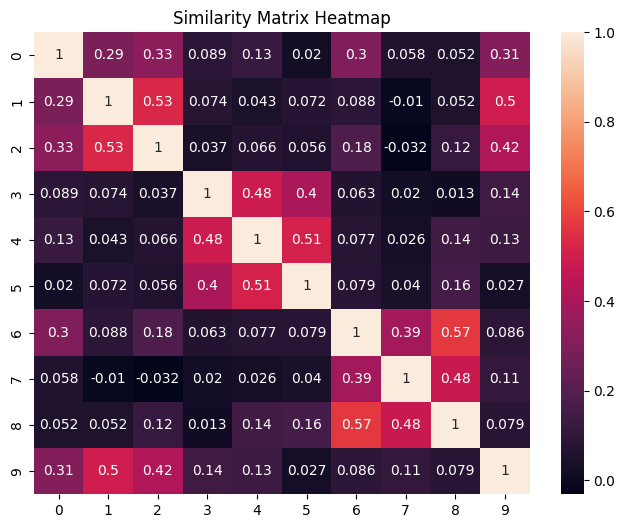

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True)
plt.title("Similarity Matrix Heatmap")
plt.show()

In [5]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarity = cosine_similarity(query_embedding, embeddings)

most_similar_index = np.argmax(similarity)

print("Query:", query)
print("Most similar sentence:", sentences[most_similar_index])

Query: The bowler took three wickets in one over
Most similar sentence: The bowler took three wickets
